In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

# Load soil data
df = pd.read_csv("/content/drive/MyDrive/Soil_OC_Project/Final_data.csv")


In [4]:
# Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

In [5]:
df.isna().sum()

,0
Lat,0
Long,0
pH,0
Ca+++Mg++_meq/lit.,0
OC_%,0
Bulk_density_g/cm3,0
Sand_%,0
Silt_%,0
Clay_%,0
MWD_mm,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Lat                 126 non-null    float64
 1   Long                126 non-null    float64
 2   pH                  126 non-null    float64
 3   Ca+++Mg++_meq/lit.  126 non-null    float64
 4   OC_%                126 non-null    float64
 5   Bulk_density_g/cm3  126 non-null    float64
 6   Sand_%              126 non-null    float64
 7   Silt_%              126 non-null    float64
 8   Clay_%              126 non-null    float64
 9   MWD_mm              126 non-null    float64
 10  CO3_meq/l           126 non-null    float64
 11  HCO3_meq/l          126 non-null    float64
dtypes: float64(12)
memory usage: 11.9 KB


In [7]:
!pip install geopandas shapely pyproj

In [8]:
import geopandas as gpd
from shapely.geometry import Point


In [9]:
print(df.columns)

Index(['Lat', 'Long', 'pH', 'Ca+++Mg++_meq/lit.', 'OC_%', 'Bulk_density_g/cm3',
       'Sand_%', 'Silt_%', 'Clay_%', 'MWD_mm', 'CO3_meq/l', 'HCO3_meq/l'],
      dtype='object')


In [10]:
# Create geometry column
geometry = [Point(xy) for xy in zip(df["Long"], df["Lat"])]

# Create GeoDataFrame
soil_gdf = gpd.GeoDataFrame(df, geometry=geometry)

# Assign CRS (WGS84)
soil_gdf = soil_gdf.set_crs(epsg=4326)

# Show first rows
soil_gdf.head()

,Lat,Long,pH,Ca+++Mg++_meq/lit.,OC_%,Bulk_density_g/cm3,Sand_%,Silt_%,Clay_%,MWD_mm,CO3_meq/l,HCO3_meq/l,geometry
0,27.235225,88.521557,6.12,1.8,3.00,1.27,74.76,9.00,16.24,1.17,0.4,0.9,POINT (88.52156 27.23522)
1,27.235346,88.499294,6.22,1.4,2.55,1.38,74.76,15.28,9.96,0.91,0.4,1.2,POINT (88.49929 27.23535)
2,27.258198,88.557298,6.15,1.8,2.62,1.35,72.76,19.48,7.76,1.04,0.5,1.1,POINT (88.5573 27.2582)
3,27.263369,88.555951,6.21,1.8,2.85,1.28,74.76,9.00,16.24,1.06,0.4,1.0,POINT (88.55595 27.26337)
4,27.266213,88.544984,6.15,1.6,2.92,1.28,67.76,10.72,21.52,1.07,0.4,1.1,POINT (88.54498 27.26621)


<Axes: >

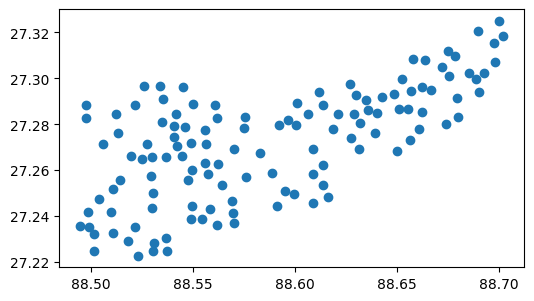

In [11]:
soil_gdf.plot(figsize=(6,6))

In [12]:
# Load study area boundary
study_area = gpd.read_file("/content/drive/MyDrive/Soil_OC_Project/Shape/study_area.shp")

# Check first rows
study_area.head()

,Id,gridcode,AREA,geometry
0,67,58,118.564,"POLYGON ((647800.491 3012590.402, 647814.098 3..."


In [13]:
print("Study area CRS:", study_area.crs)
print("Soil points CRS:", soil_gdf.crs)

Study area CRS: EPSG:32645
Soil points CRS: EPSG:4326


In [14]:
# Reproject soil points to study area CRS
soil_gdf = soil_gdf.to_crs(study_area.crs)

print("New soil CRS:", soil_gdf.crs)

New soil CRS: EPSG:32645


In [15]:
import matplotlib.pyplot as plt


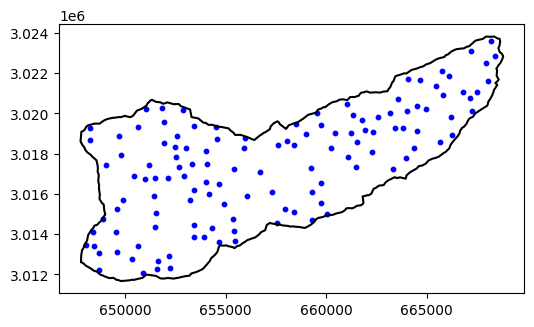

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))
study_area.boundary.plot(ax=ax, color="black")
soil_gdf.plot(ax=ax, color="blue", markersize=10)
plt.show()

In [ ]:
soil_gdf.describe()

,Lat,Long,pH,Ca+++Mg++_meq/lit.,OC_%,Bulk_density_g/cm3,Sand_%,Silt_%,Clay_%,MWD_mm,CO3_meq/l,HCO3_meq/l
count,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000
mean,27.272041,88.587278,5.668810,1.493651,3.811190,1.211429,60.740952,11.840476,29.045556,1.103254,0.443651,0.986508
std,0.024140,0.060491,0.421771,0.288096,0.860188,0.095505,8.185224,4.638570,9.137496,0.199583,0.091648,0.138190
min,27.222905,88.495027,5.090000,1.000000,2.400000,1.080000,45.760000,0.070000,2.520000,0.660000,0.300000,0.800000
25%,27.253698,88.535739,5.200000,1.400000,3.000000,1.140000,56.090000,9.000000,23.120000,0.980000,0.400000,0.900000
50%,27.276117,88.572607,5.860000,1.400000,3.670000,1.190000,58.545000,11.395000,31.540000,1.060000,0.400000,1.000000
75%,27.288789,88.638390,6.072500,1.600000,4.617500,1.277500,64.760000,16.160000,36.000000,1.210000,0.500000,1.100000
max,27.324966,88.702015,6.220000,2.000000,5.020000,1.450000,90.760000,21.440000,47.520000,1.900000,0.800000,1.200000


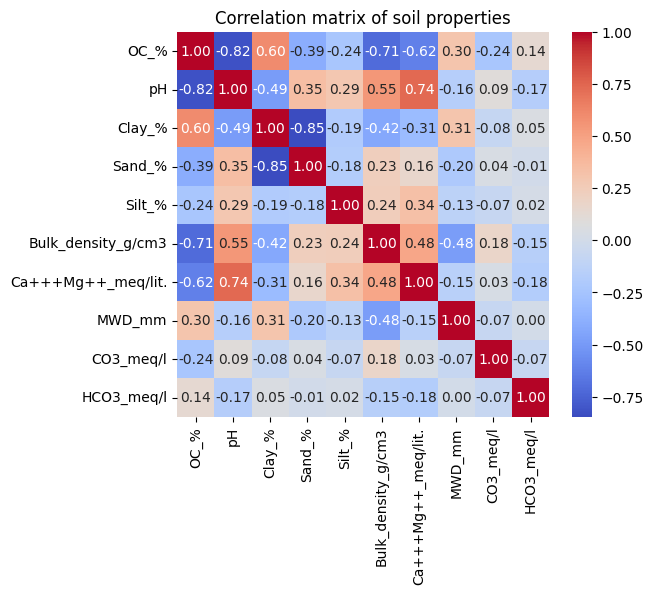

In [ ]:
import seaborn as sns

num_cols = ["OC_%", "pH", "Clay_%", "Sand_%", "Silt_%", "Bulk_density_g/cm3", "Ca+++Mg++_meq/lit.", "MWD_mm", "CO3_meq/l","HCO3_meq/l" ]

corr = soil_gdf[num_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix of soil properties")
plt.show()

In [ ]:
import numpy as np
from shapely.geometry import Point

# Grid resolution (meters)
res = 100

# Bounds of study area
minx, miny, maxx, maxy = study_area.total_bounds

# Create coordinates
x_coords = np.arange(minx, maxx, res)
y_coords = np.arange(miny, maxy, res)

# Create grid points
grid_points = [Point(x, y) for x in x_coords for y in y_coords]

# Create GeoDataFrame
grid_gdf = gpd.GeoDataFrame(geometry=grid_points, crs=study_area.crs)

# Clip to study area
grid_gdf = grid_gdf[grid_gdf.geometry.within(study_area.unary_union)]

len(grid_gdf)

/tmp/ipython-input-1025796633.py:21: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  grid_gdf = grid_gdf[grid_gdf.geometry.within(study_area.unary_union)]


11839

In [ ]:
import rasterio

In [ ]:
def extract_raster_values(raster_path, gdf, new_col):
    with rasterio.open(raster_path) as src:
        coords = [(geom.x, geom.y) for geom in gdf.geometry]
        values = [val[0] for val in src.sample(coords)]
    gdf[new_col] = values


In [ ]:
extract_raster_values("/content/drive/MyDrive/Soil_OC_Project/Covariates/Elevation.tif", soil_gdf, "elevation")
extract_raster_values("/content/drive/MyDrive/Soil_OC_Project/Covariates/Slope.tif", soil_gdf, "slope")
extract_raster_values("/content/drive/MyDrive/Soil_OC_Project/Covariates/Topographic Wetness Index.tif", soil_gdf, "twi")
extract_raster_values("/content/drive/MyDrive/Soil_OC_Project/Covariates/Aspect.tif", soil_gdf, "aspect")
extract_raster_values("/content/drive/MyDrive/Soil_OC_Project/Covariates/Flow Accumulation.tif", soil_gdf, "flow_accumulation")
extract_raster_values("/content/drive/MyDrive/Soil_OC_Project/Covariates/Plan Curvature.tif", soil_gdf, "plane_curvature")
extract_raster_values("/content/drive/MyDrive/Soil_OC_Project/Covariates/Profile Curvature.tif", soil_gdf, "profile_curvature")
extract_raster_values("/content/drive/MyDrive/Soil_OC_Project/Covariates/Stream Power Index.tif", soil_gdf, "spi")


soil_gdf[["elevation", "slope", "twi", "aspect", "flow_accumulation", "plane_curvature", "profile_curvature","spi" ]].head()


,elevation,slope,twi,aspect,flow_accumulation,plane_curvature,profile_curvature,spi
0,652,32.746128,9.224353,5.257253,41333.699219,-0.008633,-0.000333,168470.234375
1,469,31.311155,25.714037,2.976444,17529.703125,0.006122,-0.000243,-1843.358154
2,685,23.132183,8.034022,0.358771,6729.001465,-0.011223,0.000704,14681.475586
3,586,3.931096,13.181006,1.325818,534569.000000,0.008560,-0.003342,538975.937500
4,1089,17.387333,26.509251,1.130954,38826.785156,0.000573,-0.000639,-356202.593750


In [ ]:
extract_raster_values("/content/drive/MyDrive/Soil_OC_Project/Covariates/Elevation.tif", grid_gdf, "elevation")
extract_raster_values("/content/drive/MyDrive/Soil_OC_Project/Covariates/Slope.tif", grid_gdf, "slope")
extract_raster_values("/content/drive/MyDrive/Soil_OC_Project/Covariates/Topographic Wetness Index.tif", grid_gdf, "twi")
extract_raster_values("/content/drive/MyDrive/Soil_OC_Project/Covariates/Aspect.tif", grid_gdf, "aspect")
extract_raster_values("/content/drive/MyDrive/Soil_OC_Project/Covariates/Flow Accumulation.tif", grid_gdf, "flow_accumulation")
extract_raster_values("/content/drive/MyDrive/Soil_OC_Project/Covariates/Plan Curvature.tif", grid_gdf, "plane_curvature")
extract_raster_values("/content/drive/MyDrive/Soil_OC_Project/Covariates/Profile Curvature.tif", grid_gdf, "profile_curvature")
extract_raster_values("/content/drive/MyDrive/Soil_OC_Project/Covariates/Stream Power Index.tif", grid_gdf, "spi")


grid_gdf[["elevation", "slope", "twi", "aspect", "flow_accumulation", "plane_curvature", "profile_curvature","spi" ]].head()


,elevation,slope,twi,aspect,flow_accumulation,plane_curvature,profile_curvature,spi
132,316,11.499466,25.000765,4.101663,8590.218750,-0.021590,0.002565,-15579.874023
133,303,10.555381,10.083385,5.819538,50830.226562,-0.032199,-0.007495,107915.929688
134,305,3.016961,25.012697,5.034140,8693.333984,-0.001054,0.000055,-1089.106567
135,314,16.699244,8.656860,3.141593,8784.805664,-0.014815,-0.002929,13422.634766
136,367,32.383274,7.215871,3.089010,1974.514160,0.024111,0.002836,2864.887451


In [ ]:
grid_gdf[
    ["elevation", "slope", "twi", "aspect",
     "flow_accumulation", "spi"]
].describe()


,elevation,slope,twi,aspect,flow_accumulation,spi
count,11839.000000,11839.000000,11839.000000,11839.000000,1.183900e+04,1.183900e+04
mean,1547.252724,-234.983154,-244.730515,-275.129456,2.027041e+04,-4.819619e+04
std,3322.538145,5111.922852,5111.391602,5272.720215,5.373938e+04,1.389624e+06
min,303.000000,-99999.000000,-99999.000000,-99999.000000,-9.999900e+04,-9.306652e+07
25%,984.000000,19.127102,9.083635,2.231839,3.687408e+03,-8.685656e+03
50%,1318.000000,26.539566,22.744780,3.748198,7.854990e+03,-1.221697e+02
75%,1723.000000,34.354034,24.920780,5.260938,1.790963e+04,7.743373e+03
max,65535.000000,62.469372,29.755814,6.283185,2.007940e+06,2.067410e+07


In [ ]:
import numpy as np

nodata_values = [-9999, -99999, 65535]

for col in [
    "elevation", "slope", "twi", "aspect",
    "flow_accumulation", "spi"
]:
    grid_gdf[col] = grid_gdf[col].replace(nodata_values, np.nan)


In [ ]:
grid_gdf = grid_gdf.dropna(subset=[
    "elevation", "slope", "twi", "aspect",
    "flow_accumulation", "spi"
])


In [ ]:
grid_gdf[
    ["elevation", "slope", "twi", "aspect",
     "flow_accumulation", "spi"]
].describe()


,elevation,slope,twi,aspect,flow_accumulation,spi
count,11806.000000,11806.000000,11806.000000,11806.000000,1.180600e+04,1.180600e+04
mean,1379.389886,26.935759,17.156488,3.617597,2.055255e+04,-4.806833e+04
std,538.314369,10.885645,8.080048,1.809592,5.333768e+04,1.391562e+06
min,303.000000,0.954841,2.950985,0.014924,9.000000e+02,-9.306652e+07
25%,984.000000,19.188419,9.102220,2.245537,3.713065e+03,-8.505781e+03
50%,1316.000000,26.565052,22.764773,3.767078,7.887156e+03,-1.046721e+02
75%,1720.000000,34.365931,24.923961,5.264044,1.794553e+04,7.769316e+03
max,3111.000000,62.469372,29.755814,6.283185,2.007940e+06,2.067410e+07


In [ ]:
grid_gdf = grid_gdf.drop(columns=["spi"])
soil_gdf = soil_gdf.drop(columns=["spi"], errors="ignore")


In [ ]:
grid_gdf.describe()


,elevation,slope,twi,aspect,flow_accumulation,plane_curvature,profile_curvature
count,11806.000000,11806.000000,11806.000000,11806.000000,1.180600e+04,11806.000000,11806.000000
mean,1379.389886,26.935759,17.156488,3.617597,2.055255e+04,-0.000121,-0.000191
std,538.314369,10.885645,8.080048,1.809592,5.333768e+04,0.017236,0.003937
min,303.000000,0.954841,2.950985,0.014924,9.000000e+02,-0.600000,-0.020415
25%,984.000000,19.188419,9.102220,2.245537,3.713065e+03,-0.006463,-0.002467
50%,1316.000000,26.565052,22.764773,3.767078,7.887156e+03,0.000078,-0.000129
75%,1720.000000,34.365931,24.923961,5.264044,1.794553e+04,0.006860,0.002181
max,3111.000000,62.469372,29.755814,6.283185,2.007940e+06,0.272020,0.020689


In [ ]:
extract_raster_values("/content/drive/MyDrive/Soil_OC_Project/Indices/NDVI/NDVI.tif", soil_gdf, "NDVI")
extract_raster_values("/content/drive/MyDrive/Soil_OC_Project/Indices/SAVI/SAVI.tif", soil_gdf, "SAVI")
extract_raster_values("/content/drive/MyDrive/Soil_OC_Project/Indices/EVI/EVI.tif", soil_gdf, "EVI")
extract_raster_values("/content/drive/MyDrive/Soil_OC_Project/Indices/NDMI/NDMI.tif", soil_gdf, "NDMI")
extract_raster_values("/content/drive/MyDrive/Soil_OC_Project/Indices/NDBI/NDBI.tif", soil_gdf, "NDBI")
extract_raster_values("/content/drive/MyDrive/Soil_OC_Project/Indices/BSI/BSI.tif", soil_gdf, "BSI")

soil_gdf[["NDVI","SAVI","EVI","NDMI","NDBI","BSI"]].head()


,NDVI,SAVI,EVI,NDMI,NDBI,BSI
0,0.190629,0.289696,5.643695,0.057129,-0.057129,-0.027007
1,0.255257,0.387593,2.986903,0.087168,-0.087168,-0.043510
2,0.237234,0.359906,4.090632,0.047235,-0.047235,-0.022286
3,0.170269,0.255260,2.346685,0.002550,-0.002550,0.013294
4,0.278178,0.423321,4.174863,0.077576,-0.077576,-0.043965


In [ ]:
extract_raster_values("/content/drive/MyDrive/Soil_OC_Project/Indices/NDVI/NDVI.tif", grid_gdf, "NDVI")
extract_raster_values("/content/drive/MyDrive/Soil_OC_Project/Indices/SAVI/SAVI.tif", grid_gdf, "SAVI")
extract_raster_values("/content/drive/MyDrive/Soil_OC_Project/Indices/EVI/EVI.tif", grid_gdf, "EVI")
extract_raster_values("/content/drive/MyDrive/Soil_OC_Project/Indices/NDMI/NDMI.tif", grid_gdf, "NDMI")
extract_raster_values("/content/drive/MyDrive/Soil_OC_Project/Indices/NDBI/NDBI.tif", grid_gdf, "NDBI")
extract_raster_values("/content/drive/MyDrive/Soil_OC_Project/Indices/BSI/BSI.tif", grid_gdf, "BSI")

grid_gdf[["NDVI","SAVI","EVI","NDMI","NDBI","BSI"]].head()

,NDVI,SAVI,EVI,NDMI,NDBI,BSI
132,0.085902,0.127386,1.112161,-0.050872,0.050872,0.051043
133,0.069026,0.101655,0.581917,-0.075369,0.075369,0.072990
134,0.084340,0.125569,1.102144,-0.044565,0.044565,0.047482
135,0.103489,0.156272,-2.151021,-0.114290,0.114290,0.066413
136,0.265377,0.403585,4.687683,0.077841,-0.077841,-0.044212


In [ ]:
import numpy as np

landsat_cols = ["NDVI","SAVI","EVI","NDMI","NDBI","BSI"]

for col in landsat_cols:
    soil_gdf[col] = soil_gdf[col].replace([-9999, -99999], np.nan)
    grid_gdf[col] = grid_gdf[col].replace([-9999, -99999], np.nan)

# Remove soil samples with missing values
soil_gdf = soil_gdf.dropna(subset=landsat_cols)


In [ ]:
#Build FINAL X, y, coords


# Soil predictors
soil_predictors = [
    "pH",
    "Ca+++Mg++_meq/lit.",
    "Sand_%",
    "Silt_%",
    "Clay_%",
    "Bulk_density_g/cm3",
    "CO3_meq/l",
    "HCO3_meq/l",
    "MWD_mm"
]

# Terrain predictors
terrain_predictors = [
    "elevation",
    "slope",
    "twi",
    "aspect",
    "flow_accumulation"
]

# Landsat predictors
landsat_predictors = [
    "NDVI",
    "SAVI",
    "EVI",
    "NDMI",
    "NDBI",
    "BSI"
]

# Combine all
all_predictors = soil_predictors + terrain_predictors + landsat_predictors

# Build X
X = soil_gdf[all_predictors].copy()

# Target
y = soil_gdf["OC_%"].astype(float).values

# Coordinates
coords = np.vstack([
    soil_gdf.geometry.x.values,
    soil_gdf.geometry.y.values
]).T.astype(float)

print("Total predictors:", len(all_predictors))
print("X shape:", X.shape)
print("y shape:", y.shape)
print("coords shape:", coords.shape)

X.head()


Total predictors: 20
X shape: (126, 20)
y shape: (126,)
coords shape: (126, 2)


,pH,Ca+++Mg++_meq/lit.,Sand_%,Silt_%,Clay_%,Bulk_density_g/cm3,CO3_meq/l,HCO3_meq/l,MWD_mm,elevation,slope,twi,aspect,flow_accumulation,NDVI,SAVI,EVI,NDMI,NDBI,BSI
0,6.12,1.8,74.76,9.00,16.24,1.27,0.4,0.9,1.17,652,32.746128,9.224353,5.257253,41333.699219,0.190629,0.289696,5.643695,0.057129,-0.057129,-0.027007
1,6.22,1.4,74.76,15.28,9.96,1.38,0.4,1.2,0.91,469,31.311155,25.714037,2.976444,17529.703125,0.255257,0.387593,2.986903,0.087168,-0.087168,-0.043510
2,6.15,1.8,72.76,19.48,7.76,1.35,0.5,1.1,1.04,685,23.132183,8.034022,0.358771,6729.001465,0.237234,0.359906,4.090632,0.047235,-0.047235,-0.022286
3,6.21,1.8,74.76,9.00,16.24,1.28,0.4,1.0,1.06,586,3.931096,13.181006,1.325818,534569.000000,0.170269,0.255260,2.346685,0.002550,-0.002550,0.013294
4,6.15,1.6,67.76,10.72,21.52,1.28,0.4,1.1,1.07,1089,17.387333,26.509251,1.130954,38826.785156,0.278178,0.423321,4.174863,0.077576,-0.077576,-0.043965


In [ ]:
!pip install gstools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.5/129.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.2/166.2 kB 10.9 MB/s eta 0:00:00


In [ ]:
import gstools as gs


In [ ]:
def evaluate_model(y_true, y_pred, name="Model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"{name} → RMSE={rmse:.3f}, MAE={mae:.3f}, R²={r2:.3f}")
    return rmse, mae, r2


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate_model(y_true, y_pred, model_name="Model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"{model_name}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R²:   {r2:.4f}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

evaluate_model(y_test, y_pred_rf, "RF (Random split)")


RF (Random split)
RMSE: 0.3231
MAE:  0.1892
R²:   0.8300


In [ ]:
# ===============================
# Imports
# ===============================
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# ===============================
# Evaluation Function
# ===============================
def evaluate_model(y_true, y_pred, name="Model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(name)
    print(f"RMSE: {rmse:.3f}")
    print(f"MAE:  {mae:.3f}")
    print(f"R²:   {r2:.3f}\n")

    return rmse, mae, r2


# ===============================
# INPUT DATA (assumed)
# ===============================
# X      -> pandas DataFrame of features
# y      -> pandas Series or 1D numpy array
# coords -> numpy array of shape (n_samples, 2) [e.g., lon, lat]

# Example (REMOVE if already defined):
# coords = np.column_stack((X["longitude"], X["latitude"]))


# ===============================
# Spatial Blocking with KMeans
# ===============================
n_blocks = 5

kmeans = KMeans(
    n_clusters=n_blocks,
    random_state=42,
    n_init=10
)

blocks = kmeans.fit_predict(coords)


# ===============================
# Spatial Cross-Validation
# ===============================
rmse_list, mae_list, r2_list = [], [], []

for b in range(n_blocks):
    print(f"--- Block {b + 1} ---")

    train_idx = blocks != b
    test_idx = blocks == b

    rf = RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X.loc[train_idx], y[train_idx])
    y_pred = rf.predict(X.loc[test_idx])

    rmse, mae, r2 = evaluate_model(
        y[test_idx],
        y_pred,
        name=f"RF Spatial CV (Block {b + 1})"
    )

    rmse_list.append(rmse)
    mae_list.append(mae)
    r2_list.append(r2)


# ===============================
# Average Performance
# ===============================
print("=== RF Spatial CV (Average Performance) ===")
print(f"RMSE = {np.mean(rmse_list):.3f}")
print(f"MAE  = {np.mean(mae_list):.3f}")
print(f"R²   = {np.mean(r2_list):.3f}")
# ===============================
# Imports
# ===============================
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# ===============================
# Evaluation Function
# ===============================
def evaluate_model(y_true, y_pred, name="Model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(name)
    print(f"RMSE: {rmse:.3f}")
    print(f"MAE:  {mae:.3f}")
    print(f"R²:   {r2:.3f}\n")

    return rmse, mae, r2


# ===============================
# INPUT DATA (assumed)
# ===============================
# X      -> pandas DataFrame of features
# y      -> pandas Series or 1D numpy array
# coords -> numpy array of shape (n_samples, 2) [e.g., lon, lat]

# Example (REMOVE if already defined):
# coords = np.column_stack((X["longitude"], X["latitude"]))


# ===============================
# Spatial Blocking with KMeans
# ===============================
n_blocks = 5

kmeans = KMeans(
    n_clusters=n_blocks,
    random_state=42,
    n_init=10
)

blocks = kmeans.fit_predict(coords)


# ===============================
# Spatial Cross-Validation
# ===============================
rmse_list, mae_list, r2_list = [], [], []

for b in range(n_blocks):
    print(f"--- Block {b + 1} ---")

    train_idx = blocks != b
    test_idx = blocks == b

    rf = RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X.loc[train_idx], y[train_idx])
    y_pred = rf.predict(X.loc[test_idx])

    rmse, mae, r2 = evaluate_model(
        y[test_idx],
        y_pred,
        name=f"RF Spatial CV (Block {b + 1})"
    )

    rmse_list.append(rmse)
    mae_list.append(mae)
    r2_list.append(r2)


# ===============================
# Average Performance
# ===============================
print("=== RF Spatial CV (Average Performance) ===")
print(f"RMSE = {np.mean(rmse_list):.3f}")
print(f"MAE  = {np.mean(mae_list):.3f}")
print(f"R²   = {np.mean(r2_list):.3f}")


--- Block 1 ---
RF Spatial CV (Block 1)
RMSE: 0.472
MAE:  0.272
R²:   0.726

--- Block 2 ---
RF Spatial CV (Block 2)
RMSE: 0.406
MAE:  0.299
R²:   0.660

--- Block 3 ---
RF Spatial CV (Block 3)
RMSE: 0.404
MAE:  0.266
R²:   0.702

--- Block 4 ---
RF Spatial CV (Block 4)
RMSE: 0.186
MAE:  0.138
R²:   0.958

--- Block 5 ---
RF Spatial CV (Block 5)
RMSE: 0.309
MAE:  0.172
R²:   0.856

=== RF Spatial CV (Average Performance) ===
RMSE = 0.355
MAE  = 0.229
R²   = 0.780
--- Block 1 ---
RF Spatial CV (Block 1)
RMSE: 0.472
MAE:  0.272
R²:   0.726

--- Block 2 ---
RF Spatial CV (Block 2)
RMSE: 0.406
MAE:  0.299
R²:   0.660

--- Block 3 ---
RF Spatial CV (Block 3)
RMSE: 0.404
MAE:  0.266
R²:   0.702

--- Block 4 ---
RF Spatial CV (Block 4)
RMSE: 0.186
MAE:  0.138
R²:   0.958

--- Block 5 ---
RF Spatial CV (Block 5)
RMSE: 0.309
MAE:  0.172
R²:   0.856

=== RF Spatial CV (Average Performance) ===
RMSE = 0.355
MAE  = 0.229
R²   = 0.780


In [ ]:
rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

# RF predictions at soil points
y_rf = rf.predict(X)


In [ ]:
rmse_list, mae_list, r2_list = [], [], []

for b in range(n_blocks):
    train_idx = blocks != b
    test_idx = blocks == b

    # --- 1. Train RF on TRAINING data only
    rf = RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X.iloc[train_idx], y[train_idx])

    # --- 2. RF predictions
    y_rf_train = rf.predict(X.iloc[train_idx])
    y_rf_test = rf.predict(X.iloc[test_idx])

    # --- 3. Residuals on TRAINING points only
    residuals_train = y[train_idx] - y_rf_train

    # --- 4. Kriging using TRAINING points
    coords_train = coords[train_idx].T
    coords_test = coords[test_idx].T

    bin_center, gamma = gs.vario_estimate(coords_train, residuals_train)
    vmodel = gs.Exponential(dim=2)
    vmodel.fit_variogram(bin_center, gamma)

    krig = gs.krige.Ordinary(vmodel, coords_train, residuals_train)

    # --- 5. Kriged residuals at TEST points
    krig_res_test = krig(coords_test)[0]

    # --- 6. Hybrid prediction
    y_hybrid_test = y_rf_test + krig_res_test

    rmse, mae, r2 = evaluate_model(
        y[test_idx], y_hybrid_test,
        name=f"Hybrid RF + Kriging (Block {b+1})"
    )

    rmse_list.append(rmse)
    mae_list.append(mae)
    r2_list.append(r2)

print("\n Hybrid RF + Kriging (Spatial CV – FINAL):")
print(f"RMSE = {np.mean(rmse_list):.3f}")
print(f"MAE  = {np.mean(mae_list):.3f}")
print(f"R²   = {np.mean(r2_list):.3f}")


Hybrid RF + Kriging (Block 1)
RMSE: 0.475
MAE:  0.275
R²:   0.722

Hybrid RF + Kriging (Block 2)
RMSE: 0.407
MAE:  0.299
R²:   0.659

Hybrid RF + Kriging (Block 3)
RMSE: 0.402
MAE:  0.264
R²:   0.704

Hybrid RF + Kriging (Block 4)
RMSE: 0.186
MAE:  0.138
R²:   0.958

Hybrid RF + Kriging (Block 5)
RMSE: 0.310
MAE:  0.172
R²:   0.856


 Hybrid RF + Kriging (Spatial CV – FINAL):
RMSE = 0.356
MAE  = 0.230
R²   = 0.780


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


In [ ]:
rmse_list, mae_list, r2_list = [], [], []

for b in range(n_blocks):
    train_idx = blocks != b
    test_idx = blocks == b

    # Gradient Boosting model (tuned)
    gbr = GradientBoostingRegressor(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        random_state=42
    )

    gbr.fit(X.iloc[train_idx], y[train_idx])

    y_pred = gbr.predict(X.iloc[test_idx])

    rmse, mae, r2 = evaluate_model(
        y[test_idx], y_pred,
        name=f"GB Spatial CV (Block {b+1})"
    )

    rmse_list.append(rmse)
    mae_list.append(mae)
    r2_list.append(r2)

print("\n📊 Gradient Boosting (Spatial CV – FINAL):")
print(f"RMSE = {np.mean(rmse_list):.3f}")
print(f"MAE  = {np.mean(mae_list):.3f}")
print(f"R²   = {np.mean(r2_list):.3f}")


GB Spatial CV (Block 1)
RMSE: 0.360
MAE:  0.239
R²:   0.840

GB Spatial CV (Block 2)
RMSE: 0.400
MAE:  0.312
R²:   0.670

GB Spatial CV (Block 3)
RMSE: 0.382
MAE:  0.258
R²:   0.734

GB Spatial CV (Block 4)
RMSE: 0.191
MAE:  0.152
R²:   0.956

GB Spatial CV (Block 5)
RMSE: 0.350
MAE:  0.187
R²:   0.815


📊 Gradient Boosting (Spatial CV – FINAL):
RMSE = 0.337
MAE  = 0.229
R²   = 0.803


In [ ]:
rmse_list, mae_list, r2_list = [], [], []

for b in range(n_blocks):
    train_idx = blocks != b
    test_idx = blocks == b

    # ----- 1. Train Gradient Boosting on TRAIN data only
    gbr = GradientBoostingRegressor(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        random_state=42
    )

    gbr.fit(X.iloc[train_idx], y[train_idx])

    # ----- 2. GB predictions
    y_train_pred = gbr.predict(X.iloc[train_idx])
    y_test_pred = gbr.predict(X.iloc[test_idx])

    # ----- 3. Residuals (TRAIN only)
    residuals_train = y[train_idx] - y_train_pred

    # ----- 4. Kriging (TRAIN → TEST)
    coords_train = coords[train_idx].T
    coords_test = coords[test_idx].T

    bin_center, gamma = gs.vario_estimate(coords_train, residuals_train)
    vmodel = gs.Exponential(dim=2)
    vmodel.fit_variogram(bin_center, gamma)

    krig = gs.krige.Ordinary(vmodel, coords_train, residuals_train)

    krig_res_test = krig(coords_test)[0]

    # ----- 5. Hybrid prediction
    y_hybrid_test = y_test_pred + krig_res_test

    rmse, mae, r2 = evaluate_model(
        y[test_idx], y_hybrid_test,
        name=f"Hybrid GB + Kriging (Block {b+1})"
    )

    rmse_list.append(rmse)
    mae_list.append(mae)
    r2_list.append(r2)

print("\n📊 Hybrid Gradient Boosting + Kriging (Spatial CV – FINAL):")
print(f"RMSE = {np.mean(rmse_list):.3f}")
print(f"MAE  = {np.mean(mae_list):.3f}")
print(f"R²   = {np.mean(r2_list):.3f}")


Hybrid GB + Kriging (Block 1)
RMSE: 0.360
MAE:  0.239
R²:   0.840

Hybrid GB + Kriging (Block 2)
RMSE: 0.400
MAE:  0.312
R²:   0.670

Hybrid GB + Kriging (Block 3)
RMSE: 0.382
MAE:  0.258
R²:   0.734

Hybrid GB + Kriging (Block 4)
RMSE: 0.191
MAE:  0.152
R²:   0.956

Hybrid GB + Kriging (Block 5)
RMSE: 0.350
MAE:  0.187
R²:   0.815


📊 Hybrid Gradient Boosting + Kriging (Spatial CV – FINAL):
RMSE = 0.337
MAE  = 0.229
R²   = 0.803


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Final GB model
gb_final = GradientBoostingRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

# Train on all samples
gb_final.fit(X, y)


GradientBoostingRegressor(learning_rate=0.03, n_estimators=800, random_state=42,
                          subsample=0.8)

In [ ]:
# Predictors available everywhere (GRID)
mapping_predictors = [
    "elevation",
    "slope",
    "twi",
    "aspect",
    "flow_accumulation",
    "NDVI",
    "SAVI",
    "EVI",
    "NDMI",
    "NDBI",
    "BSI"
]


In [ ]:
# Training data (soil points)
X_map = soil_gdf[mapping_predictors].copy()
y_map = soil_gdf["OC_%"].values

# Train final mapping model
gb_map = GradientBoostingRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

gb_map.fit(X_map, y_map)


GradientBoostingRegressor(learning_rate=0.03, n_estimators=800, random_state=42,
                          subsample=0.8)

In [ ]:
# Grid predictors
X_grid = grid_gdf[mapping_predictors].copy()

print("Grid shape:", X_grid.shape)
X_grid.head()


Grid shape: (11806, 11)


,elevation,slope,twi,aspect,flow_accumulation,NDVI,SAVI,EVI,NDMI,NDBI,BSI
132,316.0,11.499466,25.000765,4.101663,8590.218750,0.085902,0.127386,1.112161,-0.050872,0.050872,0.051043
133,303.0,10.555381,10.083385,5.819538,50830.226562,0.069026,0.101655,0.581917,-0.075369,0.075369,0.072990
134,305.0,3.016961,25.012697,5.034140,8693.333984,0.084340,0.125569,1.102144,-0.044565,0.044565,0.047482
135,314.0,16.699244,8.656860,3.141593,8784.805664,0.103489,0.156272,-2.151021,-0.114290,0.114290,0.066413
136,367.0,32.383274,7.215871,3.089010,1974.514160,0.265377,0.403585,4.687683,0.077841,-0.077841,-0.044212


In [ ]:
# Grid predictors
X_grid = grid_gdf[mapping_predictors].copy()

print("Grid shape:", X_grid.shape)
X_grid.head()


Grid shape: (11806, 11)


,elevation,slope,twi,aspect,flow_accumulation,NDVI,SAVI,EVI,NDMI,NDBI,BSI
132,316.0,11.499466,25.000765,4.101663,8590.218750,0.085902,0.127386,1.112161,-0.050872,0.050872,0.051043
133,303.0,10.555381,10.083385,5.819538,50830.226562,0.069026,0.101655,0.581917,-0.075369,0.075369,0.072990
134,305.0,3.016961,25.012697,5.034140,8693.333984,0.084340,0.125569,1.102144,-0.044565,0.044565,0.047482
135,314.0,16.699244,8.656860,3.141593,8784.805664,0.103489,0.156272,-2.151021,-0.114290,0.114290,0.066413
136,367.0,32.383274,7.215871,3.089010,1974.514160,0.265377,0.403585,4.687683,0.077841,-0.077841,-0.044212


In [ ]:
# Predict SOC on grid
grid_gdf["SOC_GB_Map"] = gb_map.predict(X_grid)

grid_gdf[["SOC_GB_Map"]].head()


,SOC_GB_Map
132,3.418567
133,3.446669
134,3.655823
135,2.845055
136,2.896635


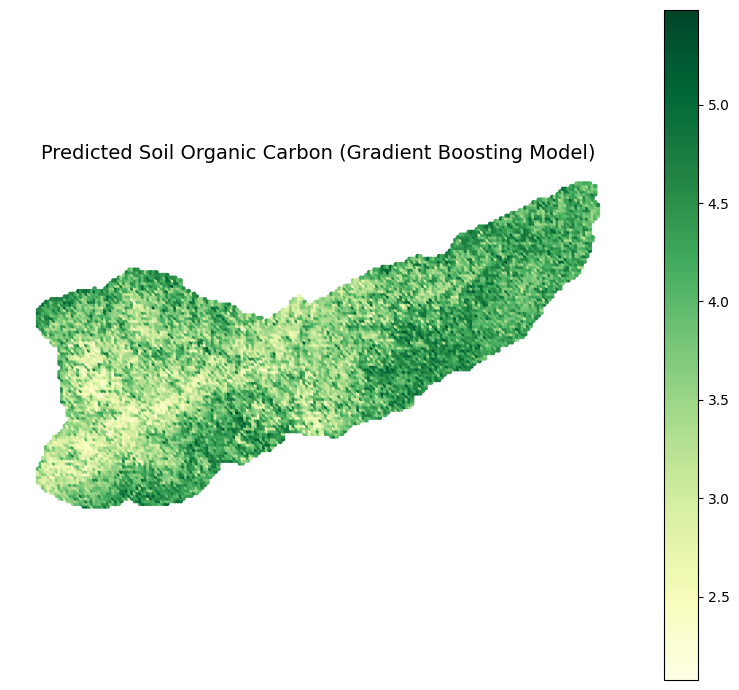

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 7))

grid_gdf.plot(
    column="SOC_GB_Map",
    cmap="YlGn",
    legend=True,
    ax=ax,
    markersize=5
)

ax.set_title("Predicted Soil Organic Carbon (Gradient Boosting Model)", fontsize=14)
ax.set_axis_off()

plt.tight_layout()
plt.show()


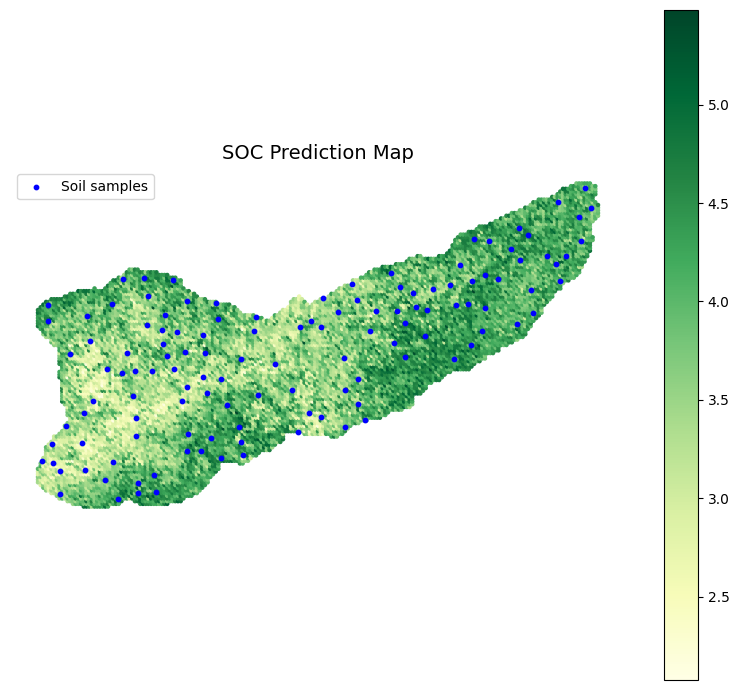

Saved!


In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))

# SOC map
grid_gdf.plot(
    column="SOC_GB_Map",
    cmap="YlGn",
    legend=True,
    ax=ax,
    markersize=5
)

# Soil sample points
soil_gdf.plot(
    ax=ax,
    color="blue",
    markersize=10,
    label="Soil samples"
)

ax.set_title("SOC Prediction Map", fontsize=14)
ax.legend()
ax.set_axis_off()

plt.tight_layout()
plt.show()

fig.savefig("SOC_prediction.png", dpi=300, bbox_inches="tight")
print("Saved!")

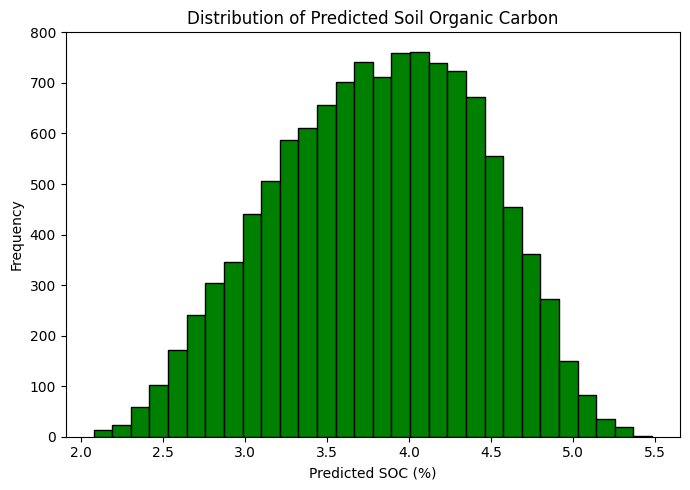

In [ ]:
plt.figure(figsize=(7,5))

plt.hist(
    grid_gdf["SOC_GB_Map"],
    bins=30,
    color="green",
    edgecolor="black"
)

plt.xlabel("Predicted SOC (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted Soil Organic Carbon")

plt.tight_layout()
plt.show()


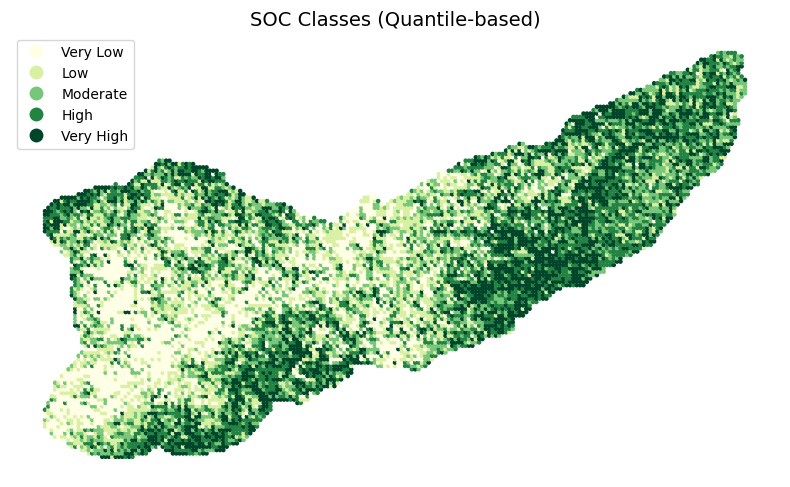

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create SOC classes using quantiles
grid_gdf["SOC_class"] = pd.qcut(
    grid_gdf["SOC_GB_Map"],
    q=5,
    labels=["Very Low", "Low", "Moderate", "High", "Very High"]
)

# Plot classified map
fig, ax = plt.subplots(figsize=(8, 7))

grid_gdf.plot(
    column="SOC_class",
    cmap="YlGn",
    legend=True,
    ax=ax,
    markersize=5
)


ax.set_title("SOC Classes (Quantile-based)", fontsize=14)
ax.set_axis_off()

plt.tight_layout()
plt.show()



In [ ]:
# Uncertinity Map Starting

#REPARE EMPTY STORAGE
import numpy as np

# Number of spatial folds
n_folds = n_blocks  # already defined earlier

# Empty list to store grid predictions
grid_predictions = []


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

mapping_predictors = [
    "elevation",
    "slope",
    "twi",
    "aspect",
    "flow_accumulation",
    "NDVI",
    "SAVI",
    "EVI",
    "NDMI",
    "NDBI",
    "BSI"
]

for b in range(n_folds):
    print(f"Processing fold {b+1}/{n_folds}")

    train_idx = blocks != b

    # Training data
    X_train = soil_gdf.loc[train_idx, mapping_predictors]
    y_train = soil_gdf.loc[train_idx, "OC_%"]

    # Grid predictors
    X_grid = grid_gdf[mapping_predictors]

    # Gradient Boosting model
    gb = GradientBoostingRegressor(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        random_state=42
    )

    gb.fit(X_train, y_train)

    # Predict on grid
    grid_pred = gb.predict(X_grid)

    # Store prediction
    grid_predictions.append(grid_pred)


Processing fold 1/5
Processing fold 2/5
Processing fold 3/5
Processing fold 4/5
Processing fold 5/5


In [ ]:
# Convert list → array
grid_predictions = np.array(grid_predictions)

print("Prediction matrix shape:", grid_predictions.shape)


Prediction matrix shape: (5, 11806)


In [ ]:
grid_gdf["SOC_uncertainty"] = np.std(grid_predictions, axis=0)


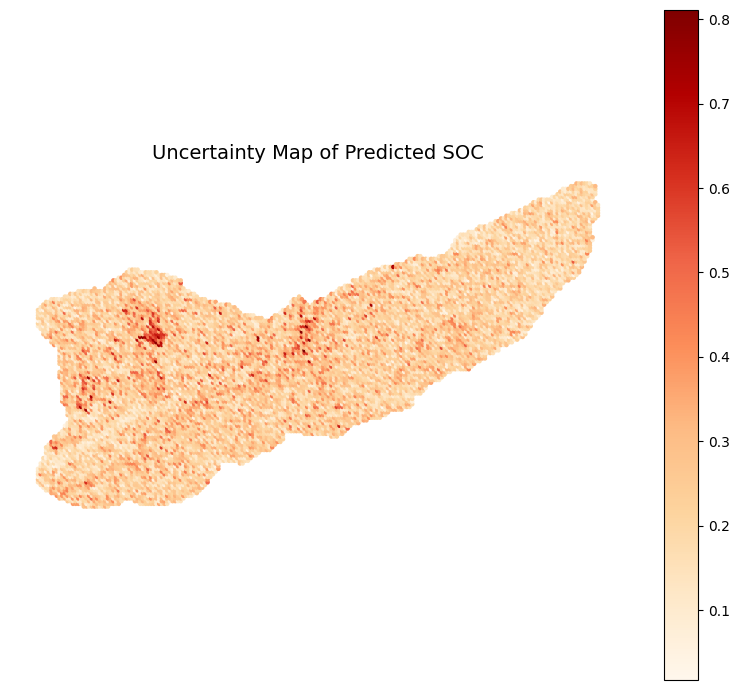

Saved!


In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 7))

grid_gdf.plot(
    column="SOC_uncertainty",
    cmap="OrRd",
    legend=True,
    ax=ax,
    markersize=5
)

ax.set_title("Uncertainty Map of Predicted SOC", fontsize=14)
ax.set_axis_off()

plt.tight_layout()
plt.show()

fig.savefig("Uncertainty_Map.png", dpi=300, bbox_inches="tight")
print("Saved!")


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

mapping_predictors = [
    "elevation",
    "slope",
    "twi",
    "aspect",
    "flow_accumulation",
    "NDVI",
    "SAVI",
    "EVI",
    "NDMI",
    "NDBI",
    "BSI"
]

X_map = soil_gdf[mapping_predictors]
y_map = soil_gdf["OC_%"]

gb_final = GradientBoostingRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

gb_final.fit(X_map, y_map)


GradientBoostingRegressor(learning_rate=0.03, n_estimators=800, random_state=42,
                          subsample=0.8)

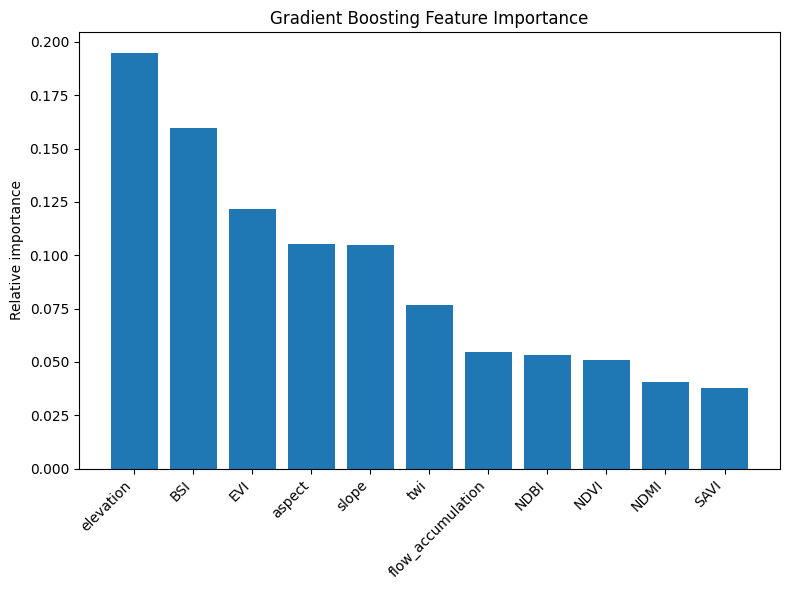

Saved!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

importances = gb_final.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8,6))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)),
           np.array(mapping_predictors)[indices],
           rotation=45, ha="right")

plt.ylabel("Relative importance")
plt.title("Gradient Boosting Feature Importance")
plt.tight_layout()
plt.show()

fig.savefig("Gradient boosting Feature Importance.png", dpi=300, bbox_inches="tight")
print("Saved!")


In [ ]:
!pip install shap


In [ ]:
import shap


In [ ]:
# Use TreeExplainer for GB model
explainer = shap.TreeExplainer(gb_final)

# SHAP values for soil points
shap_values = explainer.shap_values(X_map)


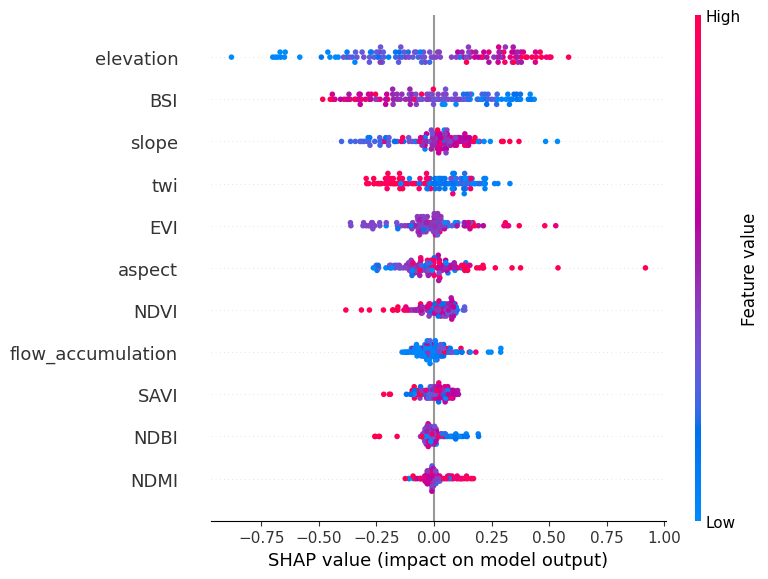

In [ ]:
shap.summary_plot(
    shap_values,
    X_map,
    plot_type="dot",
    show=True
)



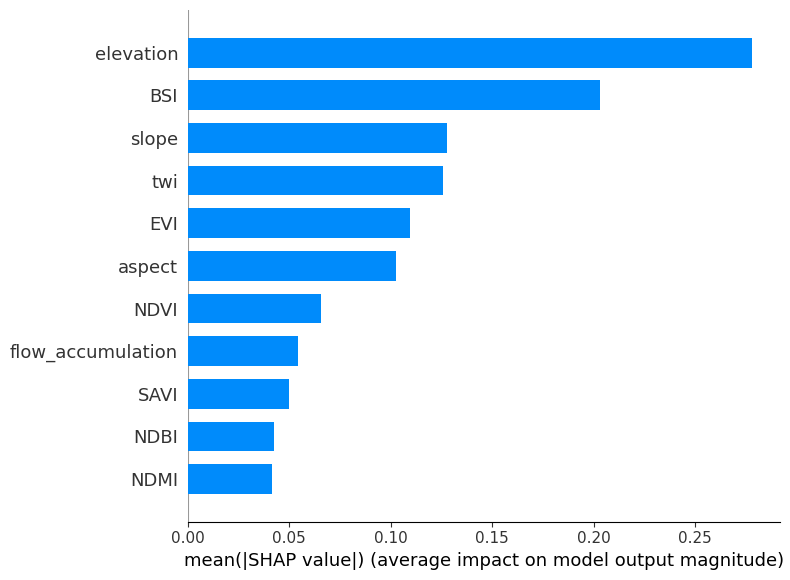

In [ ]:
shap.summary_plot(
    shap_values,
    X_map,
    plot_type="bar",
    show=True
)


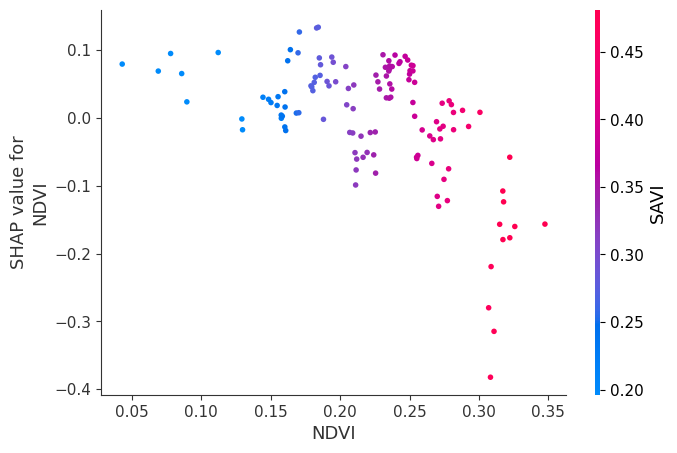

In [ ]:
shap.dependence_plot(
    "NDVI",
    shap_values,
    X_map
)


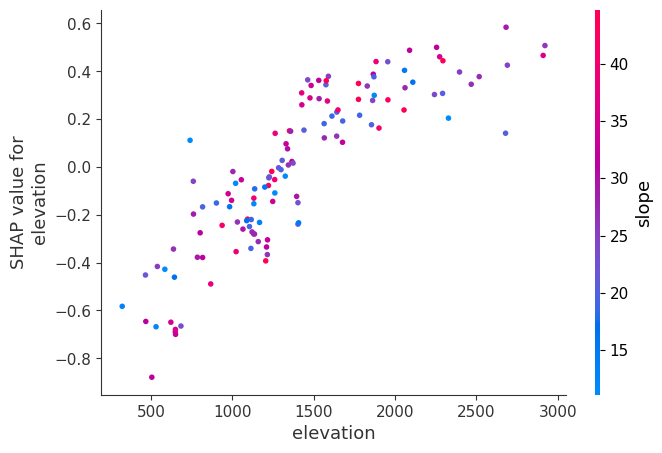

In [ ]:
shap.dependence_plot(
    "elevation",
    shap_values,
    X_map
)


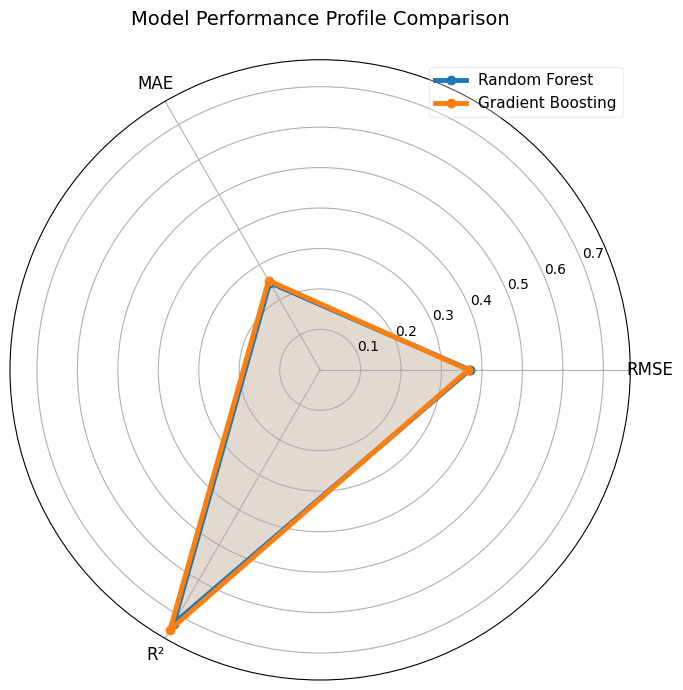

Saved!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["RMSE", "MAE", "R²"]
rf_values = [0.370, 0.249, 0.724]
gb_values = [0.366, 0.255, 0.742]

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]
rf_values += rf_values[:1]
gb_values += gb_values[:1]

fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))

# Thicker lines added here
ax.plot(angles, rf_values, linewidth=3.5, label="Random Forest", marker="o")
ax.plot(angles, gb_values, linewidth=3.5, label="Gradient Boosting", marker="o")

ax.fill(angles, rf_values, alpha=0.15)
ax.fill(angles, gb_values, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=12)
ax.set_title("Model Performance Profile Comparison", pad=25, fontsize=14)
ax.legend(loc="upper right", fontsize=11, framealpha=0.3)

plt.tight_layout()
plt.show()

fig.savefig("SOC_spider_plot.png", dpi=300, bbox_inches="tight")
print("Saved!")

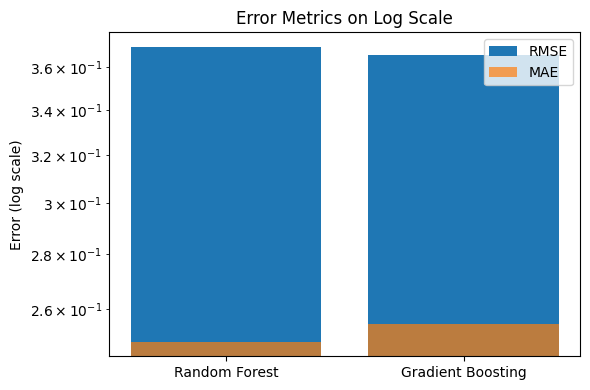

In [ ]:
import matplotlib.pyplot as plt

models = ["Random Forest", "Gradient Boosting"]
rmse = [0.370, 0.366]
mae  = [0.249, 0.255]

plt.figure(figsize=(6,4))
plt.bar(models, rmse, label="RMSE")
plt.bar(models, mae,  label="MAE", alpha=0.7)

plt.yscale("log")  # Log scale applied
plt.ylabel("Error (log scale)")
plt.title("Error Metrics on Log Scale")
plt.legend()
plt.tight_layout()
plt.show()